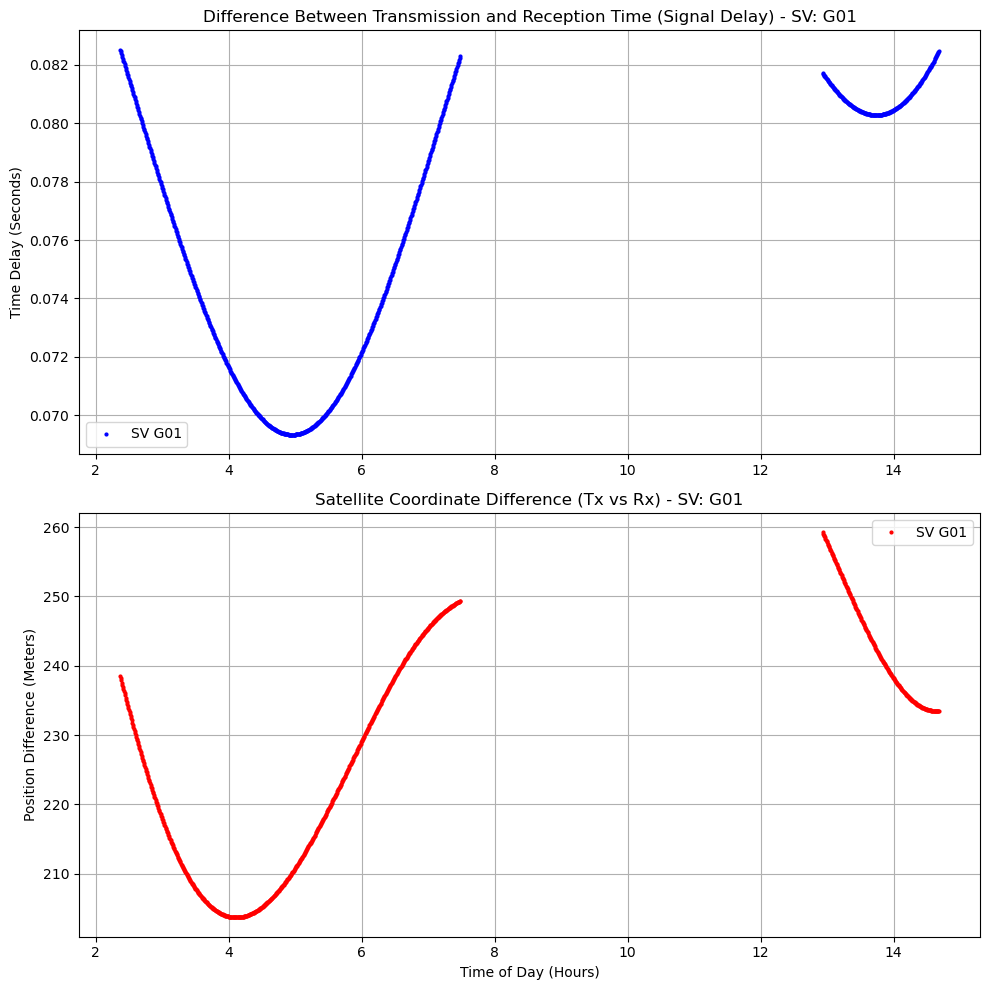

In [1]:
import numpy as np
import pandas as pd
import georinex as gr
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

c = 299792458.0           
mu = 3.986005e14          
omega_e = 7.2921151467e-5 

def calculate_satellite_position(eph, tk):
    """محاسبه مختصات ماهواره"""
    a = eph['sqrtA'].values ** 2
    e = eph['Eccentricity'].values
    M0 = eph['M0'].values
    omega = eph['omega'].values
    i0 = eph['Io'].values
    omega0 = eph['Omega0'].values
    delta_n = eph['DeltaN'].values 
    omega_dot = eph['OmegaDot'].values
    idot = eph['IDOT'].values
    Cuc, Cus = eph['Cuc'].values, eph['Cus'].values
    Crc, Crs = eph['Crc'].values, eph['Crs'].values
    Cic, Cis = eph['Cic'].values, eph['Cis'].values
    toe = eph['Toe'].values

    n0 = np.sqrt(mu / a**3)
    n = n0 + delta_n
    Mk = M0 + n * tk
    
    Ek = Mk
    for _ in range(10):
        Ek = Mk + e * np.sin(Ek)
        
    nu_k = np.arctan2(np.sqrt(1 - e**2) * np.sin(Ek), np.cos(Ek) - e)
    Phi_k = nu_k + omega
    
    du_k = Cus * np.sin(2 * Phi_k) + Cuc * np.cos(2 * Phi_k)
    dr_k = Crs * np.sin(2 * Phi_k) + Crc * np.cos(2 * Phi_k)
    di_k = Cis * np.sin(2 * Phi_k) + Cic * np.cos(2 * Phi_k)
    
    uk = Phi_k + du_k
    rk = a * (1 - e * np.cos(Ek)) + dr_k
    ik = i0 + di_k + idot * tk
    
    xk_prime = rk * np.cos(uk)
    yk_prime = rk * np.sin(uk)
    
    Omega_k = omega0 + (omega_dot - omega_e) * tk - omega_e * toe
    
    Xk = xk_prime * np.cos(Omega_k) - yk_prime * np.cos(ik) * np.sin(Omega_k)
    Yk = xk_prime * np.sin(Omega_k) + yk_prime * np.cos(ik) * np.cos(Omega_k)
    Zk = yk_prime * np.sin(ik)
    
    return np.array([Xk, Yk, Zk])

def fix_week_crossover(tk):
    """اصلاح پرش هفته GPS - طبق ICD-GPS-200"""
    if tk > 302400:
        tk -= 604800
    elif tk < -302400:
        tk += 604800
    return tk

obs = gr.load('tehn0600.17o')
nav = gr.load('BRDC00IGS_R_20170600000_01D_MN.rnx.gz')

obs_name = 'C1' 
sv_target = 'G01'

obs_sv = obs.sel(sv=sv_target).dropna(dim='time', subset=[obs_name])
nav_sv = nav.sel(sv=sv_target).dropna(dim='time', how='all')

obs_times = pd.to_datetime(obs_sv.time.values)
hours_of_day = obs_times.hour + obs_times.minute / 60.0 + obs_times.second / 3600.0

vec_r = np.array([3287010.5118, 4175373.9167, 3527263.8569]) 

tau_list = []
coord_diff_list = []

for i in range(len(obs_sv.time)):
    P_meas = obs_sv[obs_name].values[i]
    t_r_datetime = obs_times[i]
    
    time_diffs = np.abs(pd.to_datetime(nav_sv.time.values) - t_r_datetime)
    eph = nav_sv.isel(time=np.argmin(time_diffs))
    
    tk_r = (t_r_datetime - pd.to_datetime(eph.time.values)).total_seconds()
    tk_r = fix_week_crossover(tk_r)   # <-- اصلاح جدید (سازگار با بلاک ۲)
    
    tau = P_meas / c
    pos_s_tx = np.zeros(3)
    
    for _ in range(5):
        tk_s = fix_week_crossover(tk_r - tau)
        pos_s_tx = calculate_satellite_position(eph, tk_s)
        theta = omega_e * tau
        R_z = np.array([[np.cos(theta), np.sin(theta), 0], [-np.sin(theta), np.cos(theta), 0], [0, 0, 1]])
        pos_s_rotated = R_z.dot(pos_s_tx)
        tau_new = np.linalg.norm(pos_s_rotated - vec_r) / c
        if abs(tau_new - tau) < 1e-12: break
        tau = tau_new
        
    tau_list.append(tau)
    
    pos_s_rx = calculate_satellite_position(eph, tk_r)
    diff_norm = np.linalg.norm(pos_s_tx - pos_s_rx)
    coord_diff_list.append(diff_norm)

fig, axs = plt.subplots(2, 1, figsize=(10, 10))

axs[0].plot(hours_of_day, tau_list, 'b.', markersize=4, label=f'SV {sv_target}')
axs[0].set_title(f'Difference Between Transmission and Reception Time (Signal Delay) - SV: {sv_target}')
axs[0].set_ylabel('Time Delay (Seconds)')
axs[0].grid(True)
axs[0].legend()

axs[1].plot(hours_of_day, coord_diff_list, 'r.', markersize=4, label=f'SV {sv_target}')
axs[1].set_title(f'Satellite Coordinate Difference (Tx vs Rx) - SV: {sv_target}')
axs[1].set_xlabel('Time of Day (Hours)')
axs[1].set_ylabel('Position Difference (Meters)')
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()

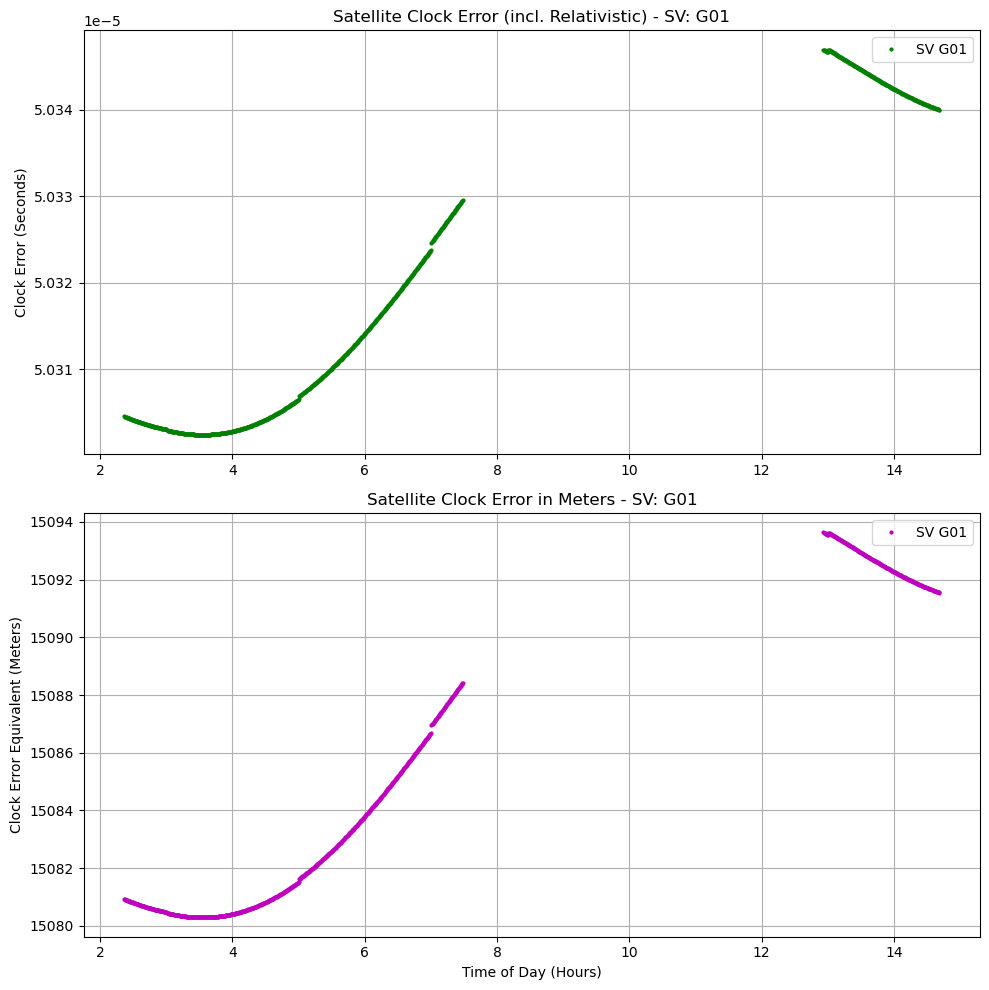

In [2]:
import numpy as np
import pandas as pd
import georinex as gr
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

mu = 3.986005e14          
F = -4.442807633e-10      
c = 299792458.0           

def calculate_satellite_clock_error(eph, tk):
    a = eph['sqrtA'].values ** 2
    e = eph['Eccentricity'].values
    M0 = eph['M0'].values
    delta_n = eph['DeltaN'].values
    
    af0 = eph['SVclockBias'].values
    af1 = eph['SVclockDrift'].values
    af2 = eph['SVclockDriftRate'].values
    
    n0 = np.sqrt(mu / a**3)
    n = n0 + delta_n
    Mk = M0 + n * tk
    
    Ek = Mk
    for _ in range(10):
        Ek = Mk + e * np.sin(Ek)
        
    dt_rel = F * e * eph['sqrtA'].values * np.sin(Ek)
    sat_clock_err_sec = af0 + af1 * tk + af2 * tk**2 + dt_rel
    # اگر لازم شد TGD هم کم شود:
    # sat_clock_err_sec -= eph['TGD'].values
    
    return sat_clock_err_sec

obs = gr.load('tehn0600.17o')
nav = gr.load('BRDC00IGS_R_20170600000_01D_MN.rnx.gz')

sv_target = 'G01'
obs_sv = obs.sel(sv=sv_target).dropna(dim='time', subset=['C1'])
nav_sv = nav.sel(sv=sv_target).dropna(dim='time', how='all')

obs_times = pd.to_datetime(obs_sv.time.values)
hours_of_day = obs_times.hour + obs_times.minute / 60.0 + obs_times.second / 3600.0

clock_error_sec_list = []
clock_error_meter_list = []

for i in range(len(obs_sv.time)):
    t_r_datetime = obs_times[i]
    time_diffs = np.abs(pd.to_datetime(nav_sv.time.values) - t_r_datetime)
    eph = nav_sv.isel(time=np.argmin(time_diffs))
    
    tk = (t_r_datetime - pd.to_datetime(eph.time.values)).total_seconds()
    if tk > 302400: tk -= 604800
    elif tk < -302400: tk += 604800
        
    clk_err_sec = calculate_satellite_clock_error(eph, tk)
    
    clock_error_sec_list.append(clk_err_sec)
    clock_error_meter_list.append(clk_err_sec * c)

fig, axs = plt.subplots(2, 1, figsize=(10, 10))

axs[0].plot(hours_of_day, clock_error_sec_list, 'g.', markersize=4, label=f'SV {sv_target}')
axs[0].set_title(f'Satellite Clock Error (incl. Relativistic) - SV: {sv_target}')
axs[0].set_ylabel('Clock Error (Seconds)')
axs[0].grid(True)
axs[0].legend()

axs[1].plot(hours_of_day, clock_error_meter_list, 'm.', markersize=4, label=f'SV {sv_target}')
axs[1].set_title(f'Satellite Clock Error in Meters - SV: {sv_target}')
axs[1].set_xlabel('Time of Day (Hours)')
axs[1].set_ylabel('Clock Error Equivalent (Meters)')
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()

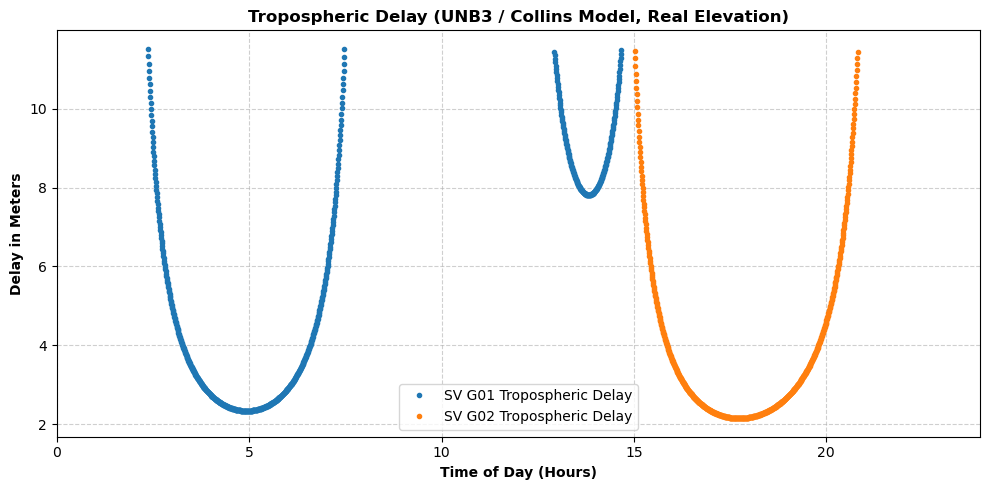

In [3]:
import numpy as np
import pandas as pd
import georinex as gr
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

c = 299792458.0
mu = 3.986005e14
omega_e = 7.2921151467e-5

def calculate_satellite_position(eph, tk):
    a = eph['sqrtA'].values ** 2
    e = eph['Eccentricity'].values
    M0 = eph['M0'].values
    omega = eph['omega'].values
    i0 = eph['Io'].values
    omega0 = eph['Omega0'].values
    delta_n = eph['DeltaN'].values
    omega_dot = eph['OmegaDot'].values
    idot = eph['IDOT'].values
    Cuc, Cus = eph['Cuc'].values, eph['Cus'].values
    Crc, Crs = eph['Crc'].values, eph['Crs'].values
    Cic, Cis = eph['Cic'].values, eph['Cis'].values
    toe = eph['Toe'].values

    n0 = np.sqrt(mu / a**3)
    n = n0 + delta_n
    Mk = M0 + n * tk
    Ek = Mk
    for _ in range(10):
        Ek = Mk + e * np.sin(Ek)
    nu_k = np.arctan2(np.sqrt(1 - e**2) * np.sin(Ek), np.cos(Ek) - e)
    Phi_k = nu_k + omega
    du_k = Cus * np.sin(2*Phi_k) + Cuc * np.cos(2*Phi_k)
    dr_k = Crs * np.sin(2*Phi_k) + Crc * np.cos(2*Phi_k)
    di_k = Cis * np.sin(2*Phi_k) + Cic * np.cos(2*Phi_k)
    uk = Phi_k + du_k
    rk = a * (1 - e*np.cos(Ek)) + dr_k
    ik = i0 + di_k + idot*tk
    xk_p = rk*np.cos(uk); yk_p = rk*np.sin(uk)
    Omega_k = omega0 + (omega_dot - omega_e)*tk - omega_e*toe
    Xk = xk_p*np.cos(Omega_k) - yk_p*np.cos(ik)*np.sin(Omega_k)
    Yk = xk_p*np.sin(Omega_k) + yk_p*np.cos(ik)*np.cos(Omega_k)
    Zk = yk_p*np.sin(ik)
    return np.array([Xk, Yk, Zk])

def fix_week_crossover(tk):
    if tk > 302400: tk -= 604800
    elif tk < -302400: tk += 604800
    return tk

def ecef2geodetic(X, Y, Z):
    """WGS84 ECEF -> lat(rad), lon(rad), h(m)"""
    a = 6378137.0
    f = 1/298.257223563
    e2 = f*(2-f)
    lon = np.arctan2(Y, X)
    p = np.sqrt(X**2 + Y**2)
    lat = np.arctan2(Z, p*(1-e2))
    for _ in range(5):
        N = a/np.sqrt(1 - e2*np.sin(lat)**2)
        h = p/np.cos(lat) - N
        lat = np.arctan2(Z, p*(1 - e2*N/(N+h)))
    N = a/np.sqrt(1 - e2*np.sin(lat)**2)
    h = p/np.cos(lat) - N
    return lat, lon, h

def compute_az_el(sat_ecef, rec_ecef, lat_r, lon_r):
    """محاسبه Azimuth و Elevation واقعی (ECEF -> ENU)"""
    dx = sat_ecef - rec_ecef
    sl, cl = np.sin(lat_r), np.cos(lat_r)
    so, co = np.sin(lon_r), np.cos(lon_r)
    R = np.array([[-so,       co,       0],
                  [-sl*co,   -sl*so,    cl],
                  [ cl*co,    cl*so,    sl]])
    enu = R.dot(dx)
    E, N, U = enu
    rng = np.linalg.norm(dx)
    el = np.arcsin(np.clip(U/rng, -1, 1))
    az = np.arctan2(E, N) % (2*np.pi)
    return az, el

lat_nodes = np.array([15, 30, 45, 60, 75])

P0_t   = np.array([1013.25, 1017.25, 1015.75, 1011.75, 1013.00])
T0_t   = np.array([299.65, 294.15, 283.15, 272.15, 263.65])
e0_t   = np.array([26.31, 21.79, 11.66, 6.78, 4.11])
beta0_t  = np.array([6.30e-3, 6.05e-3, 5.58e-3, 5.39e-3, 4.53e-3])
lam0_t = np.array([2.77, 3.15, 2.57, 1.81, 1.55])

dP_t   = np.array([0.0, -3.75, -2.25, -1.75, -0.5])
dT_t   = np.array([0.0, 7.0, 11.0, 15.0, 14.5])
de_t   = np.array([0.0, 8.85, 7.24, 5.36, 3.39])
dbeta_t = np.array([0.0, 0.25e-3, 0.32e-3, 0.81e-3, 0.62e-3])
dlam_t = np.array([0.0, 0.33, 0.46, 0.74, 0.30])

ah_avg = np.array([1.2769934e-3, 1.2683230e-3, 1.2465397e-3, 1.2196049e-3, 1.2045996e-3])
bh_avg = np.array([2.9153695e-3, 2.9152299e-3, 2.9288445e-3, 2.9022565e-3, 2.9024912e-3])
ch_avg = np.array([62.610505e-3, 62.837393e-3, 63.721774e-3, 63.824265e-3, 64.258455e-3])
ah_amp = np.array([0.0, 1.2709626e-5, 2.6523662e-5, 3.4000452e-5, 4.1202191e-5])
bh_amp = np.array([0.0, 2.1414979e-5, 3.0160779e-5, 7.2562722e-5, 11.723375e-5])
ch_amp = np.array([0.0, 9.0128400e-5, 4.3497037e-5, 84.795348e-5, 170.37206e-5])
a_ht, b_ht, c_ht = 2.53e-5, 5.49e-3, 1.14e-3

aw_avg = np.array([5.8021897e-4, 5.6794847e-4, 5.8118019e-4, 5.9727542e-4, 6.1641693e-4])
bw_avg = np.array([1.4275268e-3, 1.5138625e-3, 1.4572752e-3, 1.5007428e-3, 1.7599082e-3])
cw_avg = np.array([4.3472961e-2, 4.6729510e-2, 4.3908931e-2, 4.4626982e-2, 5.4736038e-2])

def mapping_cf(el, a, b, c):
    """تابع نگاشت به فرم کسر پیوسته (Marini/Niell)"""
    return (1 + a/(1 + b/(1+c))) / (np.sin(el) + a/(np.sin(el) + b/(np.sin(el)+c)))

def tropo_delay_unb3(lat_deg, h_m, doy, el):
    lat_abs = np.clip(abs(lat_deg), 15, 75)
    P0 = np.interp(lat_abs, lat_nodes, P0_t); dP = np.interp(lat_abs, lat_nodes, dP_t)
    T0 = np.interp(lat_abs, lat_nodes, T0_t); dT = np.interp(lat_abs, lat_nodes, dT_t)
    e0 = np.interp(lat_abs, lat_nodes, e0_t); de = np.interp(lat_abs, lat_nodes, de_t)
    beta0 = np.interp(lat_abs, lat_nodes, beta0_t); dbeta = np.interp(lat_abs, lat_nodes, dbeta_t)
    lam0 = np.interp(lat_abs, lat_nodes, lam0_t); dlam = np.interp(lat_abs, lat_nodes, dlam_t)

    Dmin = 28 if lat_deg >= 0 else 211
    eps = np.cos(2*np.pi*(doy - Dmin)/365.25)

    P = P0 - dP*eps
    T = T0 - dT*eps
    e = e0 - de*eps
    beta = beta0 - dbeta*eps
    lam = lam0 - dlam*eps

    k1, k2, Rd = 77.604, 382000.0, 287.054
    g, gm = 9.80665, 9.784

    Zh0 = 1e-6*k1*Rd*P/gm
    Zw0 = 1e-6*k2*Rd/(gm*(lam+1) - beta*Rd) * (e/T)

    Zh = Zh0*(1 - beta*h_m/T)**(g/(Rd*beta))
    Zw = Zw0*(1 - beta*h_m/T)**(((lam+1)*g)/(Rd*beta) - 1)

    ah = np.interp(lat_abs, lat_nodes, ah_avg) - np.interp(lat_abs, lat_nodes, ah_amp)*eps
    bh = np.interp(lat_abs, lat_nodes, bh_avg) - np.interp(lat_abs, lat_nodes, bh_amp)*eps
    ch = np.interp(lat_abs, lat_nodes, ch_avg) - np.interp(lat_abs, lat_nodes, ch_amp)*eps
    aw = np.interp(lat_abs, lat_nodes, aw_avg)
    bw = np.interp(lat_abs, lat_nodes, bw_avg)
    cw = np.interp(lat_abs, lat_nodes, cw_avg)

    mh = mapping_cf(el, ah, bh, ch)
    mh_ht = (1/np.sin(el) - mapping_cf(el, a_ht, b_ht, c_ht)) * (h_m/1000.0)
    mw = mapping_cf(el, aw, bw, cw)

    return Zh*(mh + mh_ht) + Zw*mw

obs = gr.load('tehn0600.17o')
nav = gr.load('BRDC00IGS_R_20170600000_01D_MN.rnx.gz')

vec_r =np.array([3240499.2152, 4049740.0674, 3701662.6813])
lat_r, lon_r, h_r = ecef2geodetic(*vec_r)
doy = 60  

sv_list = ['G01', 'G02']
cutoff_deg = 10

plt.figure(figsize=(10, 5))

for sv in sv_list:
    obs_sv = obs['C1'].sel(sv=sv).dropna(dim='time')
    nav_sv = nav.sel(sv=sv).dropna(dim='time', how='all')
    obs_times = pd.to_datetime(obs_sv.time.values)
    time_hours = obs_times.hour + obs_times.minute/60.0 + obs_times.second/3600.0

    t_valid, tropo_vals = [], []
    for i in range(len(obs_sv.time)):
        t_r = obs_times[i]
        tdiff = np.abs(pd.to_datetime(nav_sv.time.values) - t_r)
        eph = nav_sv.isel(time=np.argmin(tdiff))
        tk = fix_week_crossover((t_r - pd.to_datetime(eph.time.values)).total_seconds())
        sat_ecef = calculate_satellite_position(eph, tk)
        az, el = compute_az_el(sat_ecef, vec_r, lat_r, lon_r)
        if el < np.radians(cutoff_deg):
            continue
        delay = tropo_delay_unb3(np.degrees(lat_r), h_r, doy, el)
        t_valid.append(time_hours[i])
        tropo_vals.append(delay)

    plt.plot(t_valid, tropo_vals, marker='o', markersize=3, linestyle='',
              label=f'SV {sv} Tropospheric Delay')

plt.title('Tropospheric Delay (UNB3 / Collins Model, Real Elevation)', fontsize=12, fontweight='bold')
plt.xlabel('Time of Day (Hours)', fontweight='bold')
plt.ylabel('Delay in Meters', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xlim(0, 24)
plt.tight_layout()
plt.show()

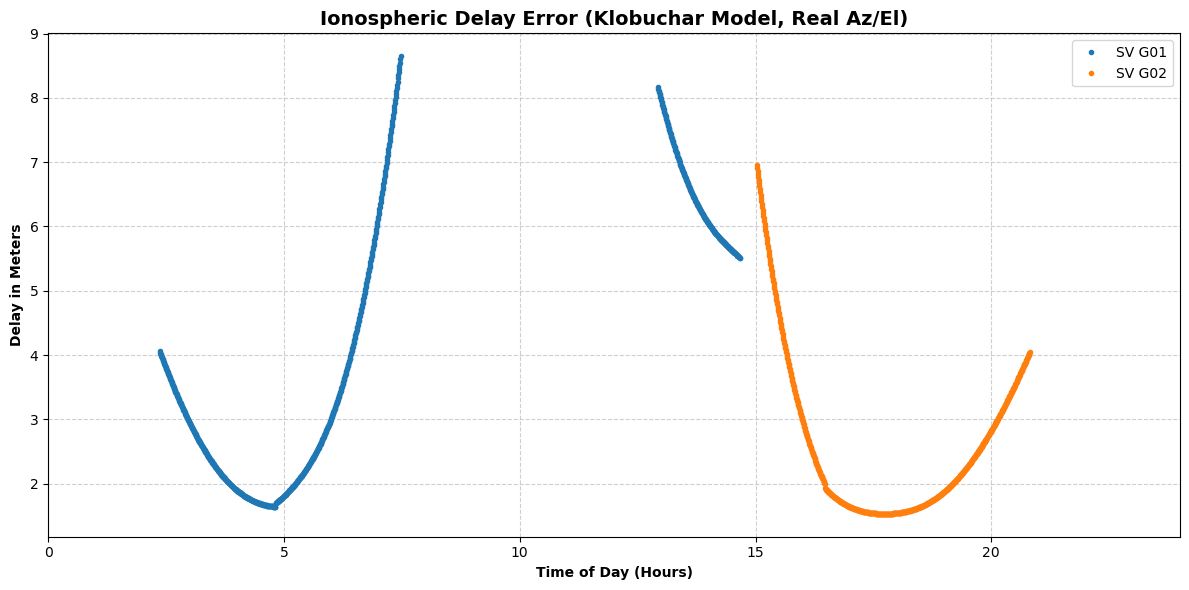

In [4]:
import numpy as np
import pandas as pd
import georinex as gr
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

c_light = 299792458.0
mu = 3.986005e14
omega_e = 7.2921151467e-5

def calculate_satellite_position(eph, tk):
    a = eph['sqrtA'].values ** 2
    e = eph['Eccentricity'].values
    M0 = eph['M0'].values
    omega = eph['omega'].values
    i0 = eph['Io'].values
    omega0 = eph['Omega0'].values
    delta_n = eph['DeltaN'].values
    omega_dot = eph['OmegaDot'].values
    idot = eph['IDOT'].values
    Cuc, Cus = eph['Cuc'].values, eph['Cus'].values
    Crc, Crs = eph['Crc'].values, eph['Crs'].values
    Cic, Cis = eph['Cic'].values, eph['Cis'].values
    toe = eph['Toe'].values
    n0 = np.sqrt(mu / a**3)
    n = n0 + delta_n
    Mk = M0 + n * tk
    Ek = Mk
    for _ in range(10):
        Ek = Mk + e * np.sin(Ek)
    nu_k = np.arctan2(np.sqrt(1 - e**2) * np.sin(Ek), np.cos(Ek) - e)
    Phi_k = nu_k + omega
    du_k = Cus * np.sin(2*Phi_k) + Cuc * np.cos(2*Phi_k)
    dr_k = Crs * np.sin(2*Phi_k) + Crc * np.cos(2*Phi_k)
    di_k = Cis * np.sin(2*Phi_k) + Cic * np.cos(2*Phi_k)
    uk = Phi_k + du_k
    rk = a * (1 - e*np.cos(Ek)) + dr_k
    ik = i0 + di_k + idot*tk
    xk_p = rk*np.cos(uk); yk_p = rk*np.sin(uk)
    Omega_k = omega0 + (omega_dot - omega_e)*tk - omega_e*toe
    Xk = xk_p*np.cos(Omega_k) - yk_p*np.cos(ik)*np.sin(Omega_k)
    Yk = xk_p*np.sin(Omega_k) + yk_p*np.cos(ik)*np.cos(Omega_k)
    Zk = yk_p*np.sin(ik)
    return np.array([Xk, Yk, Zk])

def fix_week_crossover(tk):
    if tk > 302400: tk -= 604800
    elif tk < -302400: tk += 604800
    return tk

def ecef2geodetic(X, Y, Z):
    a = 6378137.0
    f = 1/298.257223563
    e2 = f*(2-f)
    lon = np.arctan2(Y, X)
    p = np.sqrt(X**2 + Y**2)
    lat = np.arctan2(Z, p*(1-e2))
    for _ in range(5):
        N = a/np.sqrt(1 - e2*np.sin(lat)**2)
        h = p/np.cos(lat) - N
        lat = np.arctan2(Z, p*(1 - e2*N/(N+h)))
    N = a/np.sqrt(1 - e2*np.sin(lat)**2)
    h = p/np.cos(lat) - N
    return lat, lon, h

def compute_az_el(sat_ecef, rec_ecef, lat_r, lon_r):
    dx = sat_ecef - rec_ecef
    sl, cl = np.sin(lat_r), np.cos(lat_r)
    so, co = np.sin(lon_r), np.cos(lon_r)
    R = np.array([[-so,       co,       0],
                  [-sl*co,   -sl*so,    cl],
                  [ cl*co,    cl*so,    sl]])
    enu = R.dot(dx)
    E, N, U = enu
    rng = np.linalg.norm(dx)
    el = np.arcsin(np.clip(U/rng, -1, 1))
    az = np.arctan2(E, N) % (2*np.pi)
    return az, el

obs = gr.load('tehn0600.17o')
nav = gr.load('BRDC00IGS_R_20170600000_01D_MN.rnx.gz')

vec_r = np.array([3240499.2152, 4049740.0674, 3701662.6813])

lat_rx, lon_rx, h_rx = ecef2geodetic(*vec_r)

try:
    alpha = np.array(nav.attrs['ionospheric_corr_GPSA'], dtype=float)
    beta  = np.array(nav.attrs['ionospheric_corr_GPSB'], dtype=float)
except KeyError:

    alpha = [9.3132e-09, 0.0, -5.9605e-08, 0.0]
    beta  = [9.0112e+04, 0.0, -1.9661e+05, 0.0]

sv_list = ['G01', 'G02']
cutoff_deg = 10

plt.figure(figsize=(12, 6))

for sv in sv_list:
    obs_sv = obs['C1'].sel(sv=sv).dropna(dim='time')
    nav_sv = nav.sel(sv=sv).dropna(dim='time', how='all')
    obs_times = pd.to_datetime(obs_sv.time.values)
    time_hours = obs_times.hour + obs_times.minute/60.0 + obs_times.second/3600.0

    t_valid, iono_vals = [], []
    for i in range(len(obs_sv.time)):
        t_r = obs_times[i]
        tdiff = np.abs(pd.to_datetime(nav_sv.time.values) - t_r)
        eph = nav_sv.isel(time=np.argmin(tdiff))
        tk = fix_week_crossover((t_r - pd.to_datetime(eph.time.values)).total_seconds())
        sat_ecef = calculate_satellite_position(eph, tk)
        az, el = compute_az_el(sat_ecef, vec_r, lat_rx, lon_rx)
        if el < np.radians(cutoff_deg):
            continue

        # ---- الگوریتم Klobuchar با az/el واقعی ----
        el_semi = el / np.pi          # elevation در واحد semicircle
        earth_angle = 0.0137/(el_semi + 0.11) - 0.022

        lat_ipp = lat_rx/np.pi + earth_angle*np.cos(az)
        lat_ipp = np.clip(lat_ipp, -0.416, 0.416)
        lon_ipp = lon_rx/np.pi + (earth_angle*np.sin(az))/np.cos(lat_ipp*np.pi)

        geomag_lat = lat_ipp + 0.064*np.cos((lon_ipp - 1.617)*np.pi)

        t_sec = time_hours[i]*3600.0
        t_local = (43200*lon_ipp + t_sec) % 86400

        AMP = alpha[0] + alpha[1]*geomag_lat + alpha[2]*geomag_lat**2 + alpha[3]*geomag_lat**3
        AMP = max(AMP, 0)
        PER = beta[0] + beta[1]*geomag_lat + beta[2]*geomag_lat**2 + beta[3]*geomag_lat**3
        PER = max(PER, 72000)

        x = 2*np.pi*(t_local - 50400)/PER
        if abs(x) < 1.57:
            iono_vert_sec = 5e-9 + AMP*(1 - x**2/2 + x**4/24)
        else:
            iono_vert_sec = 5e-9

        F_obliq = 1.0 + 16.0*(0.53 - el_semi)**3
        iono_slant_m = F_obliq * iono_vert_sec * c_light

        t_valid.append(time_hours[i])
        iono_vals.append(iono_slant_m)

    plt.plot(t_valid, iono_vals, marker='.', linestyle='', label=f'SV {sv}')

plt.title('Ionospheric Delay Error (Klobuchar Model, Real Az/El)', fontsize=14, fontweight='bold')
plt.xlabel('Time of Day (Hours)', fontweight='bold')
plt.ylabel('Delay in Meters', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xlim(0, 24)
plt.tight_layout()
plt.show()